# Generate full paper-style visualization data

In the previous notebook, we ran the full Pig solver and stored the policy as `pig_full_policy.pkl` and the full solution as `pig_full_solution.pkl`. In this notebook, we generate the images 

Run this only after the full Pig solve has completed. The data objects correspond to the paper's main visualizations:

- Figure 3: roll/hold boundary,
- Figure 4: cross-section at opponent score 30,
- Figure 5: reachable states,
- Figure 6: reachable states where rolling is optimal,
- Figure 7: win-probability contours at 3%, 9%, 27%, and 81%.

## 1. Load in files

Note that Figure 7 requires the full value table `full_V`. If only `pig_full_policy.pkl` is available, Figures 3-6 still work and Figure 7 is skipped.

In [1]:
# Import modules
from pathlib import Path
import sys
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import piglet
import pig
import value_iteration as vi
import analysis_helpers as ah

print("Imported modules successfully.")

Imported modules successfully.


In [2]:
# Load in files
import pickle
from pathlib import Path

RUN_FULL_PIG = False
restricted_k = False
full_pig_spec = pig.make_spec(target_score=100)

solution_path = Path("pig_full_solution.pkl")
policy_path = Path("pig_full_policy.pkl")

full_V = None

if solution_path.exists():
    with solution_path.open("rb") as f:
        full_solution = pickle.load(f)

    full_policy = full_solution["policy"]
    full_V = full_solution.get("V")
    restricted_k = bool(full_solution.get("restricted_k", False))
    target_score = int(full_solution.get("target_score", 100))
    full_pig_spec = pig.make_spec(target_score=target_score)
    print(f"Loaded full solution from {solution_path}")

elif policy_path.exists():
    with policy_path.open("rb") as f:
        full_policy = pickle.load(f)

    print(f"Loaded full policy from {policy_path}")
    print("No full value table was found; Figure 7 will be skipped.")

else:
    raise FileNotFoundError(
        "Run the full Pig solve once, or place pig_full_policy.pkl / "
        "pig_full_solution.pkl in the notebook directory."
    )

print("Full policy shape:", full_policy.shape)
print("restricted_k:", restricted_k)

Loaded full solution from pig_full_solution.pkl
Full policy shape: (100, 100, 100)
restricted_k: False


In [3]:
# Change data format for figures
full_fig3_data = ah.figure3_boundary_data(full_policy)
full_fig5_data = ah.figure5_reachable_data(
    full_pig_spec,
    full_policy,
    opponent_mode="any",
    restricted_k=restricted_k,
)
full_fig4_data = ah.figure4_cross_section_data(
    full_policy,
    opponent_score=30,
    spec=full_pig_spec,
    reachable=full_fig5_data["reachable"],
    restricted_k=restricted_k,
)
full_fig6_data = ah.figure6_reachable_continue_data(
    full_pig_spec,
    full_policy,
    opponent_mode="any",
    restricted_k=restricted_k,
)

if full_V is not None:
    full_fig7_data = ah.figure7_probability_contour_data(
        full_pig_spec,
        full_V,
        levels=(0.03, 0.09, 0.27, 0.81),
        restricted_k=restricted_k,
    )
else:
    full_fig7_data = None

print("Full Figure 3 boundary points:", full_fig3_data["points"].shape)
print("Full Figure 4 transition points:", full_fig4_data["transition_points"].shape)
print("Full Figure 5 reachable points:", full_fig5_data["points"].shape)
print("Full Figure 6 reachable-roll points:", full_fig6_data["points"].shape)
if full_fig7_data is None:
    print("Full Figure 7 data skipped because full_V is not available.")

Full Figure 3 boundary points: (9984, 3)
Full Figure 4 transition points: (134, 5)
Full Figure 5 reachable points: (179577, 3)
Full Figure 6 reachable-roll points: (160879, 3)


# 2. Figure 3

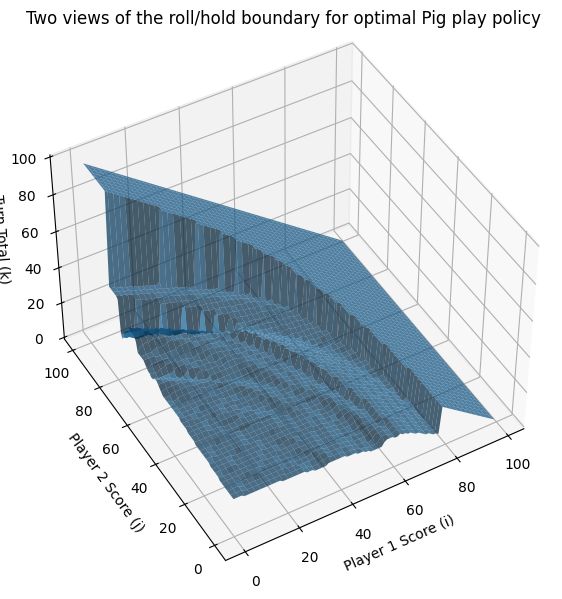

In [4]:
ax = ah.plot_figure3_policy_boundary(full_fig3_data, 
                                     title="Two views of the roll/hold boundary for optimal Pig play policy")
ax.view_init(elev=45, azim=240)
plt.savefig("Figures/Figure3a.png", bbox_inches='tight', dpi=300)
plt.show()

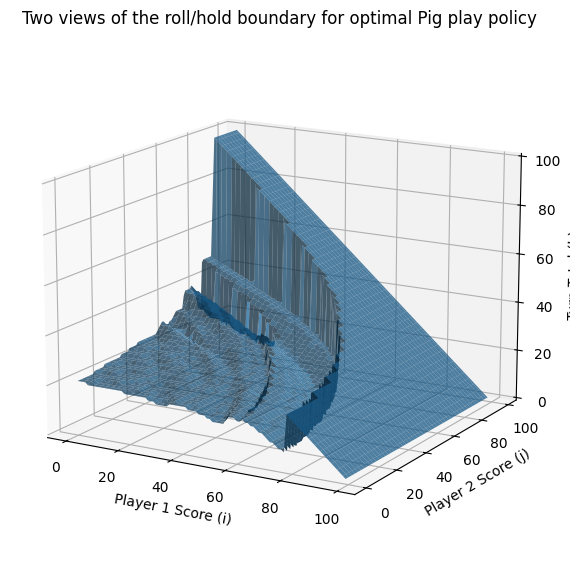

In [5]:
ax = ah.plot_figure3_policy_boundary(full_fig3_data, 
                                     title="Two views of the roll/hold boundary for optimal Pig play policy")
ax.view_init(elev=15, azim=-60)

plt.savefig("Figures/Figure3b.png", bbox_inches='tight', dpi=300)
plt.show()

# 3. Figure 4

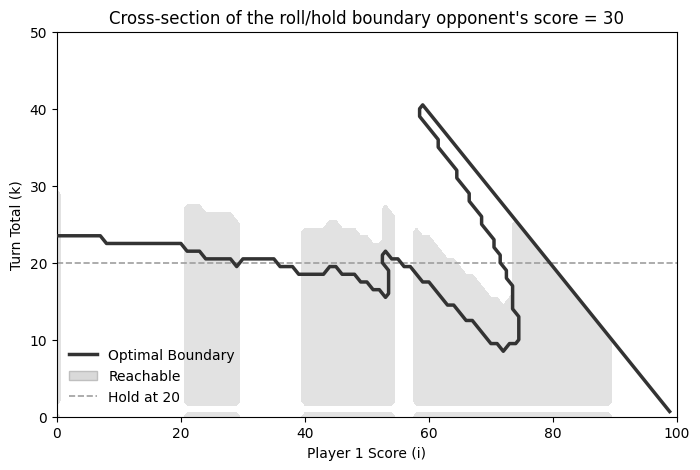

In [10]:
ah.plot_figure4_cross_section(
    full_fig4_data,
    hold_at_threshold=20,
    title="Cross-section of the roll/hold boundary opponent's score = 30"
)
plt.ylim(0, 50)
plt.xlim(0, 100)
plt.savefig("Figures/Figure4.png", bbox_inches='tight', dpi=300)
plt.show()

# 3. Figure 5

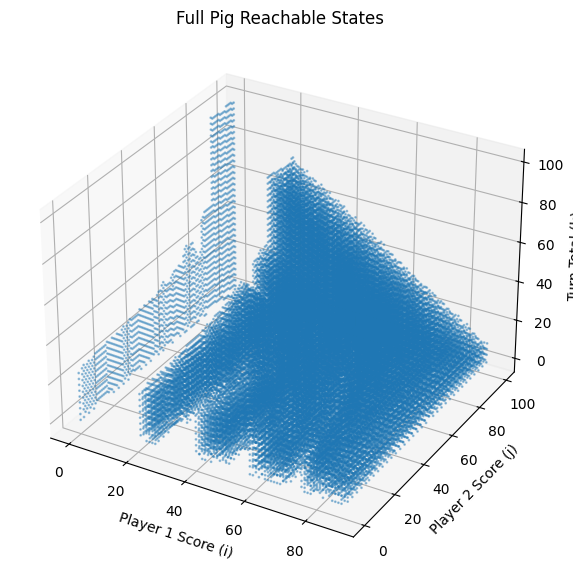

In [11]:
ah.plot_figure5_reachable_states(
    full_fig5_data,
    max_points=60000,
    title="Full Pig Reachable States"
)
plt.show()

# 4. Figure 6

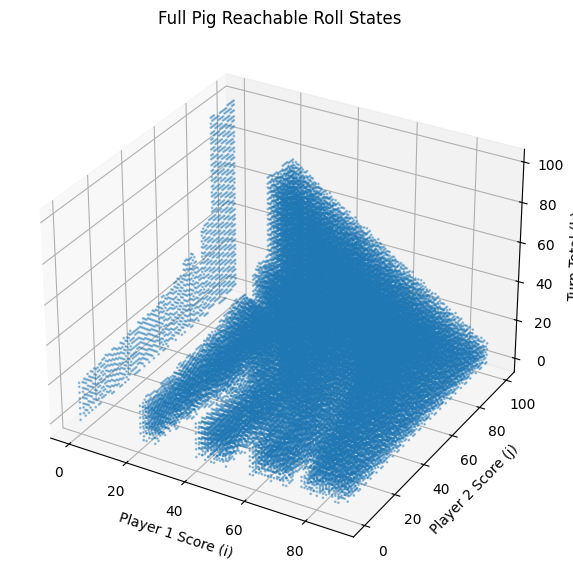

In [12]:
ah.plot_figure6_reachable_continue_states(
    full_fig6_data,
    max_points=60000,
    title="Full Pig Reachable Roll States"
)
plt.show()

# 5. Figure 7

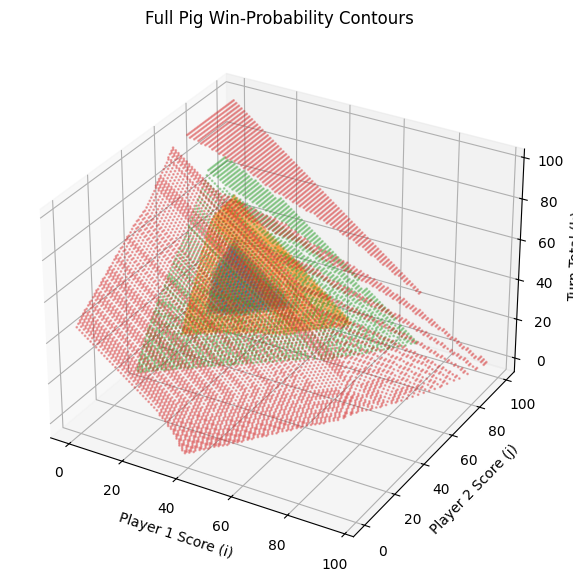

In [13]:
ah.plot_figure7_probability_contours(
    full_fig7_data,
    title="Full Pig Win-Probability Contours"
)
plt.show()